# Performance Profiling for `fivedreg` package

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from memory_profiler import memory_usage
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
# clear session
from keras.backend import clear_session

# Import fivedreg package
from fivedreg import LightweightNN

In [12]:

def polynomial_target_function(X):
    """
    Polynomial target function for synthetic data generation.

    Parameters
    ----------
    X : np.ndarray
        Input features of shape (n_samples, 5)

    Returns
    -------
    y : np.ndarray
        Target values of shape (n_samples,)
    """
    # Polynomial: x0^2 + 2*x1*x2 + x3^2 + x4 + interactions
    y = (X[:, 0]**2 +
         2 * X[:, 1] * X[:, 2] +
         X[:, 3]**2 +
         X[:, 4] +
         0.5 * X[:, 0] * X[:, 4])
    return y

def generate_synthetic_data(n_samples):
    """Generates synthetic 5D data for benchmarking."""
    np.random.seed(42)  # For reproducibility
    X = np.random.rand(n_samples, 5).astype(np.float32)
    # Polynomial target function + noise
    y = polynomial_target_function(X) + np.random.normal(0, 0.1, n_samples)
    # Reshape y to be 2D for compatibility with LightweightNN
    y = y.reshape(-1, 1)
    return X, y

def benchmark_model():
    results = []
    # Sizes required by the brief
    sizes = [100, 1000, 2500, 5000, 7500, 10000]

    print(f"{'Size':<10} | {'Epochs':<8} | {'Train Time (s)':<15} | {'Train Mem (MiB)':<15} | {'Pred Mem (MiB)':<15} | {'MSE':<10} | {'R2':<10}")
    print("-" * 95)

    for n in sizes:
        # Clear session before each run
        clear_session()

        # 1. Prepare Data
        X, y = generate_synthetic_data(n)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Convert to pandas DataFrame (as expected by fivedreg)
        X_train_df = pd.DataFrame(X_train)
        X_test_df = pd.DataFrame(X_test)
        y_train_df = pd.DataFrame(y_train)
        y_test_df = pd.DataFrame(y_test)

        baseline_mem = memory_usage(-1, interval=0.1, max_usage=True)

        # We'll use a callback to track time, or measure time around fit
        model = LightweightNN(
            hidden_layers=[64, 32, 16],
            learning_rate=0.001,
            max_iter=1,
            random_state=42,
            verbose=0
        )

        # Measure time and memory separately
        start_time = time.perf_counter()
        mem_usage_train = memory_usage((model.fit, (X_train_df, y_train_df, False)), interval=0.1)
        end_time = time.perf_counter()

        # The time includes memory profiling overhead, so we need to subtract it
        # Better: measure time in a separate run without profiling
        # But to avoid double training, let's use the history epochs to estimate
        # OR: measure time separately with a fresh model

        # Actually, let's do it properly: measure time without profiling overhead
        # Create a timing-only model
        model_timing = LightweightNN(
            hidden_layers=[64, 32, 16],
            learning_rate=0.001,
            max_iter=1,
            random_state=42,
            verbose=0
        )
        timing_start = time.perf_counter()
        model_timing.fit(X_train_df, y_train_df, early_stopping=False)
        timing_end = time.perf_counter()
        train_time = timing_end - timing_start

        # Fix 3: Track actual epochs run from the fitted model
        actual_epochs = len(model.history_.history['loss'])

        # Fix 4: Calculate absolute memory (peak - baseline)
        peak_train_mem = max(mem_usage_train)
        train_mem_absolute = peak_train_mem - baseline_mem

        # 4. Profile Prediction Memory (with baseline)
        baseline_pred_mem = memory_usage(-1, interval=0.1, max_usage=True)
        mem_usage_pred = memory_usage((model.predict, (X_test_df,)), interval=0.1)
        peak_pred_mem = max(mem_usage_pred)
        pred_mem_absolute = peak_pred_mem - baseline_pred_mem

        # 5. Calculate Accuracy Metrics
        predictions = model.predict(X_test_df)
        predictions_1d = predictions.flatten()
        y_test_1d = y_test.flatten()
        mse = mean_squared_error(y_test_1d, predictions_1d)
        r2 = r2_score(y_test_1d, predictions_1d)

        # Store results
        results.append({
            "Dataset Size": n,
            "Epochs Run": actual_epochs,
            "Training Time (s)": train_time,
            "Training Memory (MiB)": train_mem_absolute,
            "Prediction Memory (MiB)": pred_mem_absolute,
            "MSE": mse,
            "R2 Score": r2
        })

        print(f"{n:<10} | {actual_epochs:<8} | {train_time:<15.4f} | {train_mem_absolute:<15.4f} | {pred_mem_absolute:<15.4f} | {mse:<10.4f} | {r2:<10.4f}")

    return pd.DataFrame(results)

def plot_results(df):
    """Generates plots for the documentation."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Training Time Scaling
    axes[0, 0].plot(df["Dataset Size"], df["Training Time (s)"], marker='o', color='b', linewidth=2, markersize=8)
    axes[0, 0].set_title("Training Time vs Dataset Size", fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel("Number of Samples", fontsize=12)
    axes[0, 0].set_ylabel("Time (seconds)", fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xticks(df["Dataset Size"])

    # Plot 2: Memory Usage During Training
    axes[0, 1].plot(df["Dataset Size"], df["Training Memory (MiB)"], marker='s', color='r', linewidth=2, markersize=8, label='Training')
    axes[0, 1].plot(df["Dataset Size"], df["Prediction Memory (MiB)"], marker='^', color='g', linewidth=2, markersize=8, label='Prediction')
    axes[0, 1].set_title("Memory Usage vs Dataset Size", fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel("Number of Samples", fontsize=12)
    axes[0, 1].set_ylabel("Memory (MiB)", fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    axes[0, 1].set_xticks(df["Dataset Size"])

    # Plot 3: Model Error (MSE)
    axes[1, 0].plot(df["Dataset Size"], df["MSE"], marker='o', color='orange', linewidth=2, markersize=8)
    axes[1, 0].set_title("Mean Squared Error vs Dataset Size", fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel("Number of Samples", fontsize=12)
    axes[1, 0].set_ylabel("MSE", fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xticks(df["Dataset Size"])

    # Plot 4: R² Score
    axes[1, 1].plot(df["Dataset Size"], df["R2 Score"], marker='s', color='purple', linewidth=2, markersize=8)
    axes[1, 1].set_title("R² Score vs Dataset Size", fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel("Number of Samples", fontsize=12)
    axes[1, 1].set_ylabel("R² Score", fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xticks(df["Dataset Size"])
    axes[1, 1].set_ylim([None, 1.1])

    plt.tight_layout()
    plt.savefig("benchmark_plots.png", dpi=300, bbox_inches='tight')
    print("\nPlots saved to benchmark_plots.png")

Size       | Epochs   | Train Time (s)  | Train Mem (MiB) | Pred Mem (MiB)  | MSE        | R2        
-----------------------------------------------------------------------------------------------
100        | 1        | 0.5105          | 25.7031         | 1.0938          | 5.5318     | -10.5177  
1000       | 1        | 0.4778          | 8.4844          | 1.5781          | 2.3492     | -2.9676   
2500       | 1        | 0.5146          | 5.8906          | 1.2656          | 0.2024     | 0.6378    
5000       | 1        | 0.5085          | 3.9688          | 2.0312          | 0.1692     | 0.6882    
7500       | 1        | 0.5539          | 4.3438          | 1.6406          | 0.1289     | 0.7662    
10000      | 1        | 0.5470          | 4.1562          | 1.6094          | 0.0323     | 0.9431    

Plots saved to benchmark_plots.png

Results saved to benchmark_results.csv

Summary:
 Dataset Size  Epochs Run  Training Time (s)  Training Memory (MiB)  Prediction Memory (MiB)      MSE   

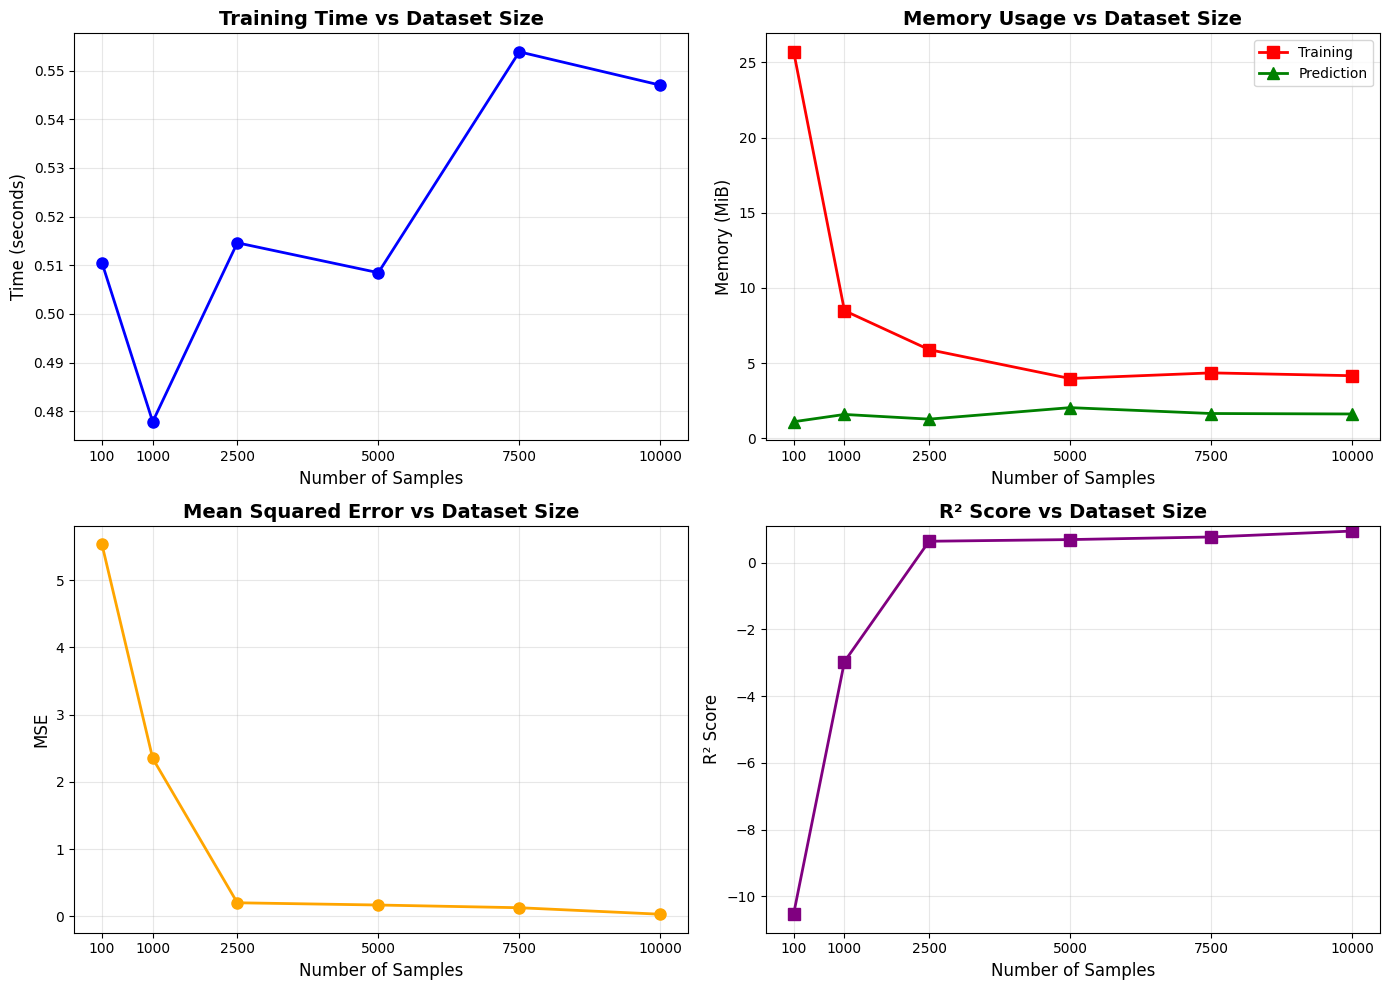

In [13]:
df_results = benchmark_model()
plot_results(df_results)
# Save raw data for the docs
df_results.to_csv("benchmark_results.csv", index=False)
print("\nResults saved to benchmark_results.csv")
print("\nSummary:")
print(df_results.to_string(index=False))